Generated dataset with 10 samples.


Training epochs:   0%|          | 0/200 [00:00<?, ?it/s]

Training epochs: 100%|██████████| 200/200 [00:07<00:00, 27.01it/s]

Training finished.
Evaluating accuracy...
Accuracy: 0.400


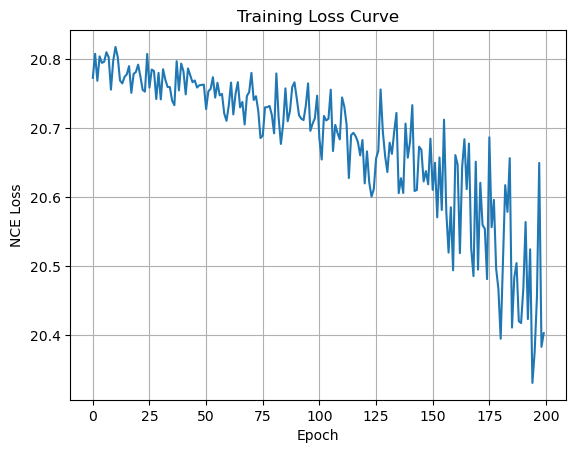

In [ ]:
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import trange
from collections import defaultdict

##################################################
# --- Data generation constants and functions ---
PROBA_COMPLEMENTARY_ITEMS = 0.7
PROBA_NEUTRAL_ITEMS = 0.3
DICT_ITEMS_CLASSES = {
    "nest0": ({0,1,2}, [-1, 1, 0, 0]) ,
    "nest1": ({3,4,5}, [1, -1, 0, 0]),
    "nest2": ({6}, [0, 0, -1, 0]),
    "nest3": ({7}, [0, 0, 0, -1])
}
ASSORTMENT = {0, 1, 2, 3, 4, 5, 6, 7}
AVAILABLE_SETS = list(KEY for KEY, VALUE in DICT_ITEMS_CLASSES.items() if VALUE[0].intersection(ASSORTMENT))

def select_first_item():
    chosen_nest = random.choice(AVAILABLE_SETS)
    chosen_item = random.choice(list(DICT_ITEMS_CLASSES[chosen_nest][0]))
    return chosen_item, chosen_nest

def complete_basket(first_item, first_nest):
    basket = {first_item}
    first_key_index = int(first_nest[-1])
    for key in AVAILABLE_SETS:
        nest, relations = DICT_ITEMS_CLASSES[key]
        if relations[first_key_index] == 1 and random.random() < PROBA_COMPLEMENTARY_ITEMS:
            basket.add(random.choice(list(nest)))
        elif relations[first_key_index] == 0 and random.random() < PROBA_NEUTRAL_ITEMS:
            basket.add(random.choice(list(nest)))
    return basket

def add_noise(basket):
    noise_proba = [0, 0.15]
    for item in ASSORTMENT:
        proba = random.choice(noise_proba)
        if item not in basket and random.random() < proba:
            basket.add(item)
    return list(basket)

##################################################

# --- Parameters ---
I = 8  # Number of items
K = 2 # Embedding dimension
DEFAULT_N_ITEMS_BASKET = 2
N_BASKET = 10
K_NOISE = 8
TRAINING_EPOCHS = 200
L_R = 0.001

# --- Model ---
class NCEBasketModel(tf.Module):
    def __init__(self, n_items, embedding_dim, K_noise, Q=None, name="NCEBasketModel"):
        super().__init__(name=name)
        self.n_items = n_items
        self.embedding_dim = embedding_dim
        self.K_noise = K_noise
        self.optimizer = tf.keras.optimizers.Adam(L_R)
        self.Wi = tf.Variable(tf.random.normal((embedding_dim, n_items), stddev=0.1), name='Wi')
        self.Wo = tf.Variable(tf.random.normal((n_items, embedding_dim), stddev=0.1), name='Wo')
        self.wa = tf.Variable(tf.random.normal((embedding_dim,), stddev=0.1), name='wa')
        if Q is None:
            self.Q = tf.constant([1.0/(n_items-1)]*n_items, dtype=tf.float32)
        else:
            self.Q = tf.constant(Q, dtype=tf.float32)

    def context_embed(self, context_items):

        context_emb = tf.gather(self.Wi, context_items, axis=1)

        attn_logits = tf.tensordot(self.wa, context_emb, axes=1)
        attn_weights = tf.nn.softmax(attn_logits)
        context_vec = tf.reduce_sum(context_emb * tf.expand_dims(attn_weights, axis=0), axis=1)
        return context_vec

    def score(self, context_vec, item):
        return tf.tensordot(self.Wo[item], context_vec, axes=1)

    def bad_loss(self, context_items, target_item):
        context_vec = self.context_embed(context_items)
        scores = tf.tensordot(self.Wo, context_vec, axes=1)  
        #exp_scores = tf.exp(scores)
        #log_prob = scores[target_item] - tf.math.log(tf.reduce_sum(exp_scores))
        return tf.math.log(tf.nn.softmax(scores)[target_item])

    def train_step(self, batch):
        def basket_loss(basket):
            target_item = random.choice(basket)
            context_items = [i for i in basket if i != target_item]
            return self.bad_loss(context_items, target_item)
        with tf.GradientTape() as tape:
            losses = tf.stack([basket_loss(basket) for basket in batch])
            total_loss = -tf.reduce_sum(losses)
        grads = tape.gradient(total_loss, [self.Wi, self.wa, self.Wo])
        self.optimizer.apply_gradients(zip(grads, [self.Wi, self.wa, self.Wo]))
        return float(total_loss.numpy())
    
    def predict(self, context_items):
        context_vec = self.context_embed(context_items)
        scores = tf.tensordot(self.Wo, context_vec, axes=1)
        return scores

##################################################

def generate_dataset(n_basket, n_items_basket=DEFAULT_N_ITEMS_BASKET):
    baskets = []
    count = 0
    while count < n_basket:
        first_item, first_nest = select_first_item()
        basket = complete_basket(first_item, first_nest)
        basket = add_noise(basket)
        if len(basket) == n_items_basket:
            baskets.append(basket)
            count += 1

    return baskets

# --- Training ---
def train_model():
    dataset = generate_dataset(N_BASKET)
    print(f"Generated dataset with {len(dataset)} samples.")
    model = NCEBasketModel(I, K, K_NOISE)
    loss_history = []

    for epoch in trange(TRAINING_EPOCHS, desc="Training epochs"):

        loss = model.train_step(dataset)
        loss_history.append(loss)

    return model, dataset, loss_history

# --- Evaluation ---
def evaluate(model, dataset):
    correct = 0
    for basket in dataset:
        target_item = random.choice(list(basket))
        context_items = [item for item in basket if item != target_item]
        scores = model.predict(context_items)
        # Mask context items so they can't be predicted
        mask = np.ones(I, dtype=bool)
        mask[context_items] = False
        scores_np = scores.numpy()
        scores_np[~mask] = -np.inf
        pred = np.argmax(scores_np)
        if pred == target_item:
            correct += 1
    return correct / len(dataset)

# --- Main ---
if __name__ == "__main__":
    model, dataset, loss_history = train_model()
    print("Training finished.")
    print("Evaluating accuracy...")
    acc = evaluate(model, dataset)
    print(f"Accuracy: {acc:.3f}")
    plt.plot(loss_history)
    plt.xlabel("Epoch")
    plt.ylabel("NCE Loss")
    plt.title("Training Loss Curve")
    plt.grid(True)
    plt.show()

Model predictions P(i|j) on random baskets:
 [[0.028 0.031 0.02  0.038 0.014 0.    0.029 0.022]
 [0.201 0.279 0.21  0.221 0.007 0.14  0.127 0.233]
 [0.06  0.036 0.097 0.016 0.046 0.095 0.    0.056]
 [0.247 0.231 0.243 0.434 0.501 0.321 0.256 0.255]
 [0.081 0.133 0.088 0.069 0.187 0.102 0.06  0.157]
 [0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.374 0.29  0.331 0.192 0.246 0.333 0.52  0.264]
 [0.009 0.    0.011 0.029 0.    0.009 0.009 0.013]]


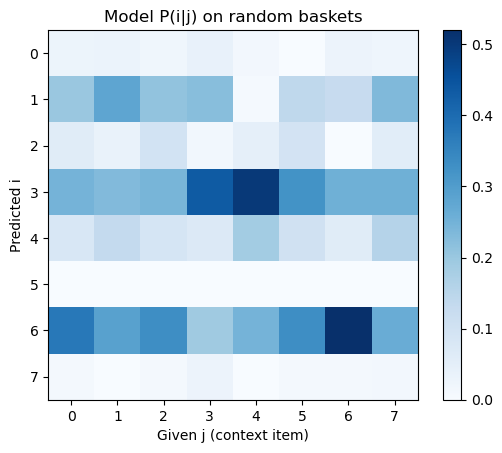

In [66]:
##################################################
# Test the model on random baskets

# Parameters

N_RANDOM_BASKETS = 1000
MIN_BASKET_SIZE = 2
MAX_BASKET_SIZE = 5

# Generate random baskets
random_baskets = []
for _ in range(N_RANDOM_BASKETS):
    basket_size = np.random.randint(MIN_BASKET_SIZE, MAX_BASKET_SIZE + 1)
    basket = np.random.choice(range(I), size=basket_size, replace=False).tolist()
    random_baskets.append(basket)

# Collect predictions: P(i|context)
P_ij_random = np.zeros((I, I))  # Rows: predicted, Cols: context item

for basket in random_baskets:
    for j in basket:
        context = [i for i in basket if i != j]
        if not context:
            continue
        scores = model.predict(tf.constant(context, dtype=tf.int32)).numpy()
        # Mask context items so they can't be predicted
        mask = np.ones(I, dtype=bool)
        mask[context] = False
        scores[~mask] = -np.inf
        i_pred = np.argmax(scores)
        P_ij_random[i_pred, j] += 1

# Normalize: P(i|j) = count(i,j) / count(j)
P_ij_random_norm = P_ij_random / (np.sum(P_ij_random, axis=0, keepdims=True) + 1e-10)

print("Model predictions P(i|j) on random baskets:\n", np.round(P_ij_random_norm, 3))
import matplotlib.pyplot as plt
plt.imshow(P_ij_random_norm, cmap='Blues')
plt.xlabel('Given j (context item)')
plt.ylabel('Predicted i')
plt.title('Model P(i|j) on random baskets')
plt.colorbar()
plt.show()

Empirical P(i|j) from data:
 [[0.    0.056 0.064 0.134 0.138 0.145 0.125 0.118]
 [0.056 0.    0.057 0.138 0.136 0.143 0.126 0.126]
 [0.06  0.052 0.    0.125 0.128 0.129 0.117 0.111]
 [0.13  0.132 0.13  0.    0.076 0.069 0.113 0.116]
 [0.142 0.139 0.141 0.081 0.    0.058 0.124 0.129]
 [0.157 0.154 0.15  0.078 0.061 0.    0.134 0.128]
 [0.239 0.238 0.239 0.224 0.231 0.238 0.    0.272]
 [0.217 0.23  0.219 0.22  0.231 0.217 0.262 0.   ]]


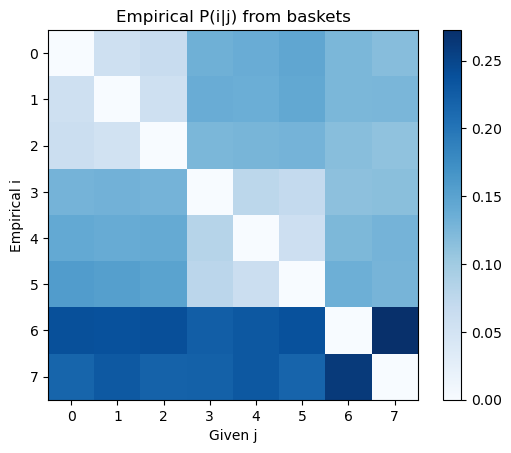

In [3]:
##################################################
# Original distribution

# Generate baskets
N_SAMPLES = 1000
baskets = []
count = 0
while count < N_SAMPLES:
    first_item, first_nest = select_first_item()
    basket = complete_basket(first_item, first_nest)
    basket = add_noise(basket)
    if len(basket) < 2:
        continue
    baskets.append(basket)
    count += 1

# Compute empirical P(i|j) from baskets
P_ij_true = np.zeros((I, I))
for basket in baskets:
    for i in basket:
        for j in basket:
            if i != j:
                P_ij_true[i, j] += 1

# Normalize: P(i|j) = count(i,j) / count(j)
P_ij_true_norm = P_ij_true / (np.sum(P_ij_true, axis=0, keepdims=True) + 1e-10)

print("Empirical P(i|j) from data:\n", np.round(P_ij_true_norm, 3))
plt.imshow(P_ij_true_norm, cmap='Blues')
plt.xlabel('Given j')
plt.ylabel('Empirical i')
plt.title('Empirical P(i|j) from baskets')
plt.colorbar()
plt.show()

In [18]:
"""
##################################################
# Grid search for best parameters

from itertools import product
import numpy as np
import tensorflow as tf
from NCEBasketModel import NCEBasketModel
from generate_dataset import generate_dataset


def pij_distance(P1, P2):
    return np.mean((P1 - P2) ** 2)

param_grid = {
    'K': [2, 4, 8],
    'K_NOISE': [4, 6, 8],
    'L_R': [0.01, 0.05, 0.1]
}

best_score = float('inf')
best_params = None

for K, K_NOISE, L_R in product(param_grid['K'], param_grid['K_NOISE'], param_grid['L_R']):
    print(f"Testing K={K}, K_NOISE={K_NOISE}, L_R={L_R}")
    # Train model with these parameters
    model = NCEBasketModel(I, K, K_NOISE)
    optimizer = tf.keras.optimizers.Adam(L_R)
    dataset = generate_dataset(N_BASKET)
    for epoch in range(30):  # Fewer epochs for speed
        batch = random.sample(dataset, min(16, len(dataset)))
        model.train_step(batch, optimizer)
    # Compute model P(i|j) using softmax
    P_ij_soft = np.zeros((I, I))
    for basket in baskets:
        for j in basket:
            context_wo_j = [i for i in basket if i != j]
            if not context_wo_j:
                continue
            scores = model.predict(tf.constant(context_wo_j, dtype=tf.int32)).numpy()
            mask = np.ones(I, dtype=bool)
            mask[context_wo_j] = False
            scores[~mask] = -np.inf
            probs = np.exp(scores - np.max(scores))
            probs = probs * mask
            probs = probs / (probs.sum() + 1e-10)
            P_ij_soft[:, j] += probs
    P_ij_soft_norm = P_ij_soft / (np.sum(P_ij_soft, axis=0, keepdims=True) + 1e-10)
    # Compute distance
    score = pij_distance(P_ij_soft_norm, P_ij_true_norm)
    print(f"Distance: {score:.5f}")
    if score < best_score:
        best_score = score
        best_params = {'K': K, 'K_NOISE': K_NOISE, 'L_R': L_R}

print("Best params:", best_params)
print("Best distance:", best_score)
"""

'\n##################################################\n# Grid search for best parameters\n\nfrom itertools import product\nimport numpy as np\nimport tensorflow as tf\nfrom NCEBasketModel import NCEBasketModel\nfrom generate_dataset import generate_dataset\n\n\ndef pij_distance(P1, P2):\n    return np.mean((P1 - P2) ** 2)\n\nparam_grid = {\n    \'K\': [2, 4, 8],\n    \'K_NOISE\': [4, 6, 8],\n    \'L_R\': [0.01, 0.05, 0.1]\n}\n\nbest_score = float(\'inf\')\nbest_params = None\n\nfor K, K_NOISE, L_R in product(param_grid[\'K\'], param_grid[\'K_NOISE\'], param_grid[\'L_R\']):\n    print(f"Testing K={K}, K_NOISE={K_NOISE}, L_R={L_R}")\n    # Train model with these parameters\n    model = NCEBasketModel(I, K, K_NOISE)\n    optimizer = tf.keras.optimizers.Adam(L_R)\n    dataset = generate_dataset(N_BASKET)\n    for epoch in range(30):  # Fewer epochs for speed\n        batch = random.sample(dataset, min(16, len(dataset)))\n        model.train_step(batch, optimizer)\n    # Compute model P(i|j